# Metryki: problem klasyfikacji

https://scikit-learn.org/stable/modules/model_evaluation.html

## Import bibliotek

In [3]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, RocCurveDisplay

**Metryki - Klasyfikacja binarna**

**Accuracy - Dokładność klasyfikacji**

$$Accuracy = \frac{correct\ predictions}{total\ predictions} * 100$$

In [39]:
y_true = np.array([1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1])
y_pred = np.array([0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1])

In [40]:
from sklearn.metrics import accuracy_score
accuracy_score(y_true, y_pred)

0.8

In [41]:
results = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred})

## Macierz konfuzji/pomyłek

In [42]:
cm = confusion_matrix(y_true, y_pred)

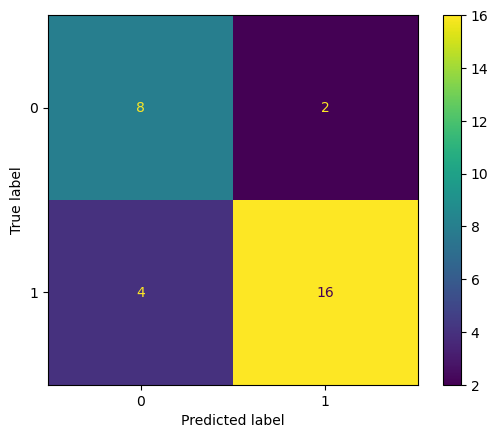

In [43]:
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot();

In [44]:
tn, fp, fn, tp = cm.ravel()
print(f'TN - True Negative: {tn}')
print(f'FP - False Positive: {fp}')
print(f'FN - False Negative: {fn}')
print(f'TP - True Positive: {tp}')

TN - True Negative: 8
FP - False Positive: 2
FN - False Negative: 4
TP - True Positive: 16


In [45]:
# Type I error - False Positive Rate
fpr = fp / (fp + tn)
fpr

np.float64(0.2)

In [46]:
# Type II error - False Negative Rate
fnr = fn / (fn + tp)
fnr

np.float64(0.2)

In [47]:
# Precision - ile obserwacji przewidywanych jako pozytywne są w rzeczywistości pozytywne
precision = tp / (tp + fp)
print(precision)

0.8888888888888888


In [48]:
# Recall - jak wiele obserwacji z wzystkich poytywnych sklasyfikowaliśmy jako pozytywne
recall = tp / (tp + fn)
print(recall)

0.8


## Krzywa ROC

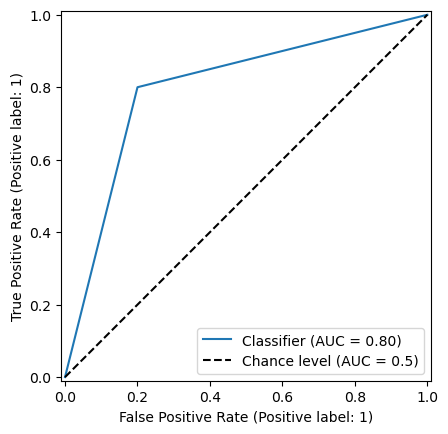

In [56]:
RCD = RocCurveDisplay.from_predictions(
    y_true,
    y_pred,
    plot_chance_level=True,
    chance_level_kw={"linestyle": "--"},
    pos_label = 1,
)

plt.show()

## Metryki - Klasyfikacja wieloklasowa

## Accuracy - Dokładność klasyfikacji

$$Accuracy = \frac{correct\ predictions}{total\ predictions} * 100$$

In [57]:
y_true = np.array([1, 0, 1, 2, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 2, 1, 1, 2, 2, 1, 0, 1, 1, 0, 2, 1, 1, 2, 2])
y_pred = np.array([0, 0, 1, 2, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 2, 1, 2, 1, 2, 1, 0, 2, 1, 0, 1, 1, 1, 2, 2])

accuracy_score(y_true, y_pred)

0.7241379310344828

## Macierz konfuzji/pomyłek

In [58]:
cm = confusion_matrix(y_true, y_pred)
cm

array([[ 6,  1,  0],
       [ 3, 10,  2],
       [ 0,  2,  5]])

In [59]:
cmr = cm.ravel() 
cmr

array([ 6,  1,  0,  3, 10,  2,  0,  2,  5])

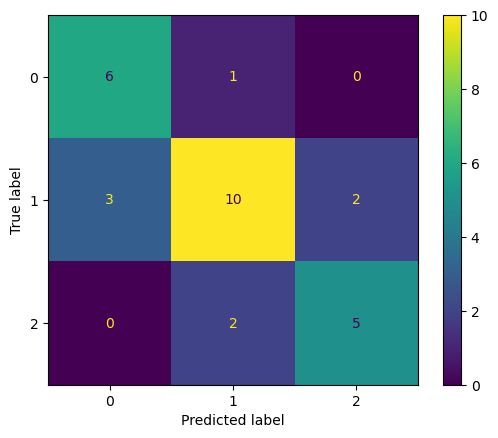

In [60]:
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

## Raport klasyfikacji

In [61]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.86      0.75         7
           1       0.77      0.67      0.71        15
           2       0.71      0.71      0.71         7

    accuracy                           0.72        29
   macro avg       0.72      0.75      0.73        29
weighted avg       0.73      0.72      0.72        29



In [62]:
print(classification_report(y_true, y_pred, target_names=['label_1', 'label_2', 'label_3']))

              precision    recall  f1-score   support

     label_1       0.67      0.86      0.75         7
     label_2       0.77      0.67      0.71        15
     label_3       0.71      0.71      0.71         7

    accuracy                           0.72        29
   macro avg       0.72      0.75      0.73        29
weighted avg       0.73      0.72      0.72        29



# Metryki "uśredniane"

To nie są osobne „metryki”, tylko **sposoby uśredniania** metryk liczonych dla każdej klasy osobno (najczęściej **precision, recall, F1**) w klasyfikacji wieloklasowej lub wieloetykietowej. W `scikit-learn` są one zdefiniowane właśnie jako warianty parametru `average`.

**Micro**

* Najpierw sumujemy globalnie wszystkie:

  * **TP** (true positives),
  * **FP** (false positives),
  * **FN** (false negatives),
* a dopiero potem liczymy metrykę z tych łącznych wartości.
  
  Czyli traktujemy wszystkie decyzje modelu tak, jakby pochodziły z jednego dużego problemu binarnego.

Dla przykładu:

* **micro-precision** = suma TP / (suma TP + suma FP)
* **micro-recall** = suma TP / (suma TP + suma FN)

**Kiedy stosować:**

* gdy chcemy znać **ogólną skuteczność na poziomie wszystkich obserwacji**,
* gdy ważny jest łączny wynik modelu, a nie równe traktowanie każdej klasy,
* często w **multilabel**,
* w niezbalansowanych danych trzeba uważać, bo wynik może być silnie zdominowany przez klasy najczęstsze.

W pełnej klasyfikacji wieloklasowej `micro` często nie jest osobno pokazywane, w `classification_report`, bo odpowiada **accuracy**.

**Macro**

* Liczymy daną metrykę osobno dla każdej klasy,
* potem bierzemy **zwykłą średnią arytmetyczną** z wyników klas.

Czyli każda klasa ma **taką samą wagę**, niezależnie od tego, czy ma 10 przykładów, czy 10 000. `scikit-learn` definiuje to jako „unweighted mean”, który **nie uwzględnia niezbalansowania klas**. 

**Kiedy stosować:**

* gdy **każda klasa jest równie ważna**,
* gdy chcemy sprawdzić, czy model nie ignoruje klas mniejszościowych,
* bardzo dobre do oceny na **danych niezbalansowanych**, jeśli zależy Nam na uczciwym spojrzeniu na wszystkie klasy, a nie tylko na dominującą.

To zwykle lepszy wybór niż `micro`, gdy chcesmy ocenić jakość modelu z perspektywy klas rzadkich. To jest praktyczny wniosek z definicji `macro` jako średniej bez wag.

**Weighted**

* Liczymy metrykę osobno dla każdej klasy,
* potem bierzemy średnią, ale **ważoną przez support**,
* gdzie **support** to liczba prawdziwych przykładów danej klasy w `y_true`.

Czyli:

* klasy częstsze wpływają na wynik bardziej,
* klasy rzadkie wpływają mniej.

`scikit-learn` opisuje to jako wersję `macro`, która została skorygowana o niezbalansowanie klas przez ważenie supportem.

**Kiedy stosować:**

* gdy mamy **niezbalansowane klasy**, ale chcemy jedną liczbę podsumowującą wynik modelu w sposób zbliżony do rzeczywistego rozkładu danych,
* gdy klasy częstsze naprawdę są ważniejsze z punktu widzenia zastosowania,
* gdy chcemy raport „ogólnej jakości”, ale nie aż tak zdominowany globalnym zliczaniem jak `micro`.

Trzeba jednak pamiętać, że `weighted` może wyglądać dobrze nawet wtedy, gdy model słabo radzi sobie z klasami rzadkimi, bo klasy większościowe mają większy wpływ. `scikit-learn` zaznacza też, że dla F-score wynik ważony może nie leżeć między precision i recall.

Najprostsze zalecenie praktyczne:

* **micro** — gdy interesuje Nas **łączna skuteczność wszystkich predykcji**,
* **macro** — gdy interesuje Nas **równe traktowanie wszystkich klas**,
* **weighted** — gdy chcemy **jedną liczbę uwzględniającą proporcje klas**.

W praktyce, przy danych niezbalansowanych, często warto raportować **co najmniej dwie wartości naraz**:

* **macro** (czy model nie krzywdzi klas rzadkich),
* **weighted** albo **micro** (jaki jest wynik ogólny).

To jest rekomendacja interpretacyjna wynikająca z tego, że każda z tych średnich odpowiada na inne pytanie.

* https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_fscore_support.html
* https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html
* https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html